In [1]:
# for some basic operations
import numpy as np
import pandas as pd

# for visualizations
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import dabl

## Reading the Data

In [2]:
# reading the data
data = pd.read_excel('StudentsPerformance1.xls')

# getting the shape of the data
data.shape

(1000, 8)

In [3]:
# looking at the head of the data

data.head()

,gender,tools,level of education,mental health,test mode,score before pandemic,score after pandemic,aggregate score
0,female,Computer,bachelor's degree,normal,online,72,72,72.0
1,female,Mobile,college,normal,offline,69,90,79.5
2,female,Computer,college,normal,online,90,95,92.5
3,male,Tablet,associate's degree,stressed,online,47,57,52.0
4,male,Mobile,college,normal,online,76,78,77.0


## Descriptive Statistics

In [4]:
# describing the dataset

data.describe()

,score before pandemic,score after pandemic,aggregate score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,67.628000
std,15.16308,14.600192,14.185445
min,0.00000,17.000000,8.500000
25%,57.00000,59.000000,58.500000
50%,66.00000,70.000000,68.000000
75%,77.00000,79.000000,77.500000
max,100.00000,100.000000,100.000000


In [5]:
# lets check the no. of unique items present in the categorical column

data.select_dtypes('object').nunique()

gender                2
tools                 4
level of education    5
mental health         2
test mode             2
dtype: int64

In [6]:
# lets check the percentage of missing data in each columns present in the data

no_of_columns = data.shape[0]
percentage_of_missing_data = data.isnull().sum()/no_of_columns
print(percentage_of_missing_data)

gender                   0.0
tools                    0.0
level of education       0.0
mental health            0.0
test mode                0.0
score before pandemic    0.0
score after pandemic     0.0
aggregate score          0.0
dtype: float64


** Checking for Skewness for the Before Pandemic , After Pandemic and Aggregate of both**

D:\Software\Anaconda\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
D:\Software\Anaconda\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
D:\Software\Anaconda\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function 

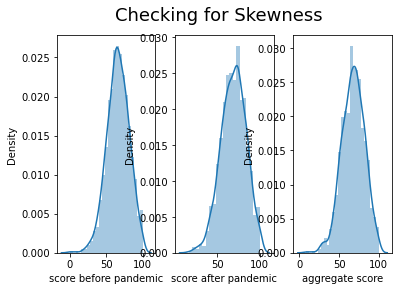

In [7]:
plt.subplot(1, 3, 1)
sns.distplot(data['score before pandemic'])

plt.subplot(1, 3, 2)
sns.distplot(data['score after pandemic'])

plt.subplot(1, 3, 3)
sns.distplot(data['aggregate score'])

plt.suptitle('Checking for Skewness', fontsize = 18)
plt.show()

- It is very much clear, that there is no skewness in the Target Columns.

## Lets check the Inference

In [8]:
# lets take seed so that everytime the random values come out to be constant
np.random.seed(6)

# lets take 100 sample values from the dataset of 1000 values
sample_score_before_pandemic = np.random.choice(a= data['score before pandemic'], size=100)

# getting the sample mean
print ("Sample mean for Score Before Pandemic:", sample_score_before_pandemic.mean() )          

# getting the population mean
print("Population mean for Score Before Pandemic:", data['score before pandemic'].mean())

# lets take 100 sample values from the dataset of 1000 values
sample_score_after_pandemic = np.random.choice(a= data['score after pandemic'], size=100)

# getting the sample mean
print ("\nSample mean for Score After Pandemic:", sample_score_after_pandemic.mean() )          

# getting the population mean
print("Population mean for Score After Pandemic:", data['score after pandemic'].mean())

# lets take 100 sample values from the dataset of 1000 values
sample_aggregate_score = np.random.choice(a= data['aggregate score'], size=100)

# getting the sample mean
print ("\nSample mean for Aggregate Score:", sample_aggregate_score.mean() )          

# getting the population mean
print("Population mean for Aggregate Score:", data['aggregate score'].mean())

Sample mean for Score Before Pandemic: 63.12
Population mean for Score Before Pandemic: 66.089

Sample mean for Score After Pandemic: 68.5
Population mean for Score After Pandemic: 69.169

Sample mean for Aggregate Score: 70.59
Population mean for Aggregate Score: 67.628


** Let check the Confidence Interval for Score Before Pandemic**

In [9]:
# lets import the scipy package
import scipy.stats as stats
import math

# lets seed the random values
np.random.seed(10)

# lets take a sample size
sample_size = 1000
sample = np.random.choice(a= data['score before pandemic'],
                          size = sample_size)
sample_mean = sample.mean()

# Get the z-critical value*
z_critical = stats.norm.ppf(q = 0.95)  

 # Check the z-critical value  
print("z-critical value: ",z_critical)                                

# Get the population standard deviation
pop_stdev = data['score before pandemic'].std()  

# checking the margin of error
margin_of_error = z_critical * (pop_stdev/math.sqrt(sample_size)) 

# defining our confidence interval
confidence_interval = (sample_mean - margin_of_error,
                       sample_mean + margin_of_error)  

# lets print the results
print("Confidence interval:",end=" ")
print(confidence_interval)
print("True mean: {}".format(data['score before pandemic'].mean()))

z-critical value:  1.6448536269514722
Confidence interval: (64.82729483328328, 66.40470516671672)
True mean: 66.089


** Let check the Confidence Interval for Score After Pandemic**

In [10]:
# lets import the scipy package
import scipy.stats as stats
import math

# lets seed the random values
np.random.seed(10)

# lets take a sample size
sample_size = 1000
sample = np.random.choice(a= data['score after pandemic'],
                          size = sample_size)
sample_mean = sample.mean()

# Get the z-critical value*
z_critical = stats.norm.ppf(q = 0.95)  

 # Check the z-critical value  
print("z-critical value: ",z_critical)                                

# Get the population standard deviation
pop_stdev = data['score after pandemic'].std()  

# checking the margin of error
margin_of_error = z_critical * (pop_stdev/math.sqrt(sample_size)) 

# defining our confidence interval
confidence_interval = (sample_mean - margin_of_error,
                       sample_mean + margin_of_error)  

# lets print the results
print("Confidence interval:",end=" ")
print(confidence_interval)
print("True mean: {}".format(data['score after pandemic'].mean()))

z-critical value:  1.6448536269514722
Confidence interval: (67.75757337011645, 69.27642662988355)
True mean: 69.169


- Notice that the true mean is contained in our interval.
- A confidence interval of 69% would mean that if we take many samples and create confidence intervals for each of them, 69% of our samples' confidence intervals will contain the true population mean.


## Grouping Operations

### Number of Girl/Female Students Scoring 90 in all factors

In [11]:
data[(data['gender'] == 'female') &
     (data['score before pandemic'] > 90) & 
     (data['score after pandemic'] > 90) &
     (data['aggregate score'] > 90)]

,gender,tools,level of education,mental health,test mode,score before pandemic,score after pandemic,aggregate score
114,female,Mobile,bachelor's degree,normal,offline,99,100,99.5
165,female,Mobile,bachelor's degree,normal,offline,96,100,98.0
179,female,Laptop,some school,normal,offline,97,100,98.5
263,female,Mobile,school,normal,online,99,93,96.0
451,female,Mobile,college,normal,online,100,92,96.0
458,female,Mobile,bachelor's degree,normal,online,100,100,100.0
546,female,Tablet,some school,normal,offline,92,100,96.0
566,female,Mobile,bachelor's degree,stressed,offline,92,100,96.0
594,female,Mobile,bachelor's degree,normal,offline,92,100,96.0
685,female,Mobile,college,normal,offline,94,99,96.5


### Lets compare the scores secured by Boys and Girls

In [12]:
data.groupby(['gender']).agg(['min','median','max'])

score before pandemic             score after pandemic              \
                         min median  max                  min median  max   
gender                                                                      
female                     0     65  100                   17     73  100   
male                      27     69  100                   23     66  100   

       aggregate score                
                   min median    max  
gender                                
female             8.5   68.5  100.0  
male              25.5   67.5  100.0

### Lets check the Effect of Mental Health on Student's Performnce

In [13]:
data[['mental health','gender','score before pandemic','score after pandemic','aggregate score']].groupby(['mental health','gender']).agg('median')

score before pandemic  score after pandemic  \
mental health gender                                                
normal        female                   67.0                  75.0   
              male                     72.0                  67.5   
stressed      female                   57.0                  67.0   
              male                     62.0                  61.0   

                      aggregate score  
mental health gender                   
normal        female             72.0  
              male               70.0  
stressed      female             62.0  
              male               62.0

### Lets check the Effect of Diffrent Modes on Scores

In [14]:
data[['test mode',
      'gender',
      'score before pandemic',
      'score after pandemic',
      'aggregate score']].groupby(['test mode','gender']).agg('median')

score before pandemic  score after pandemic  aggregate score
test mode gender                                                              
offline   female                     67                    78            72.75
          male                       73                    71            72.00
online    female                     62                    71            66.00
          male                       67                    63            64.50

### Lets check the Effect of Digital Tools on Student's Performance

In [15]:
data[['tools',
      'score before pandemic',
      'score after pandemic',
      'aggregate score']].groupby(['tools']).agg('median')

,score before pandemic,score after pandemic,aggregate score
tools,,,
Computer,63,67,64.75
Laptop,69,71,69.50
Mobile,67,72,69.50
Tablet,61,64,62.00


### Data Visualizations

D:\Software\Anaconda\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


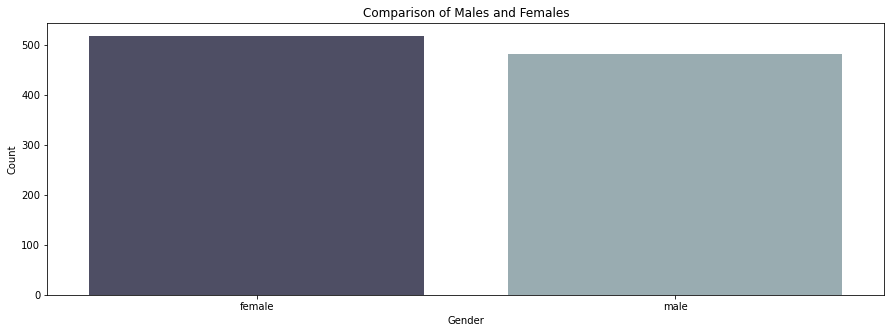

In [16]:
# visualising the number of male and female in the dataset

plt.rcParams['figure.figsize'] = (15, 5)

sns.countplot(data['gender'], palette = 'bone')
plt.title('Comparison of Males and Females', fontweight = 30)
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

D:\Software\Anaconda\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


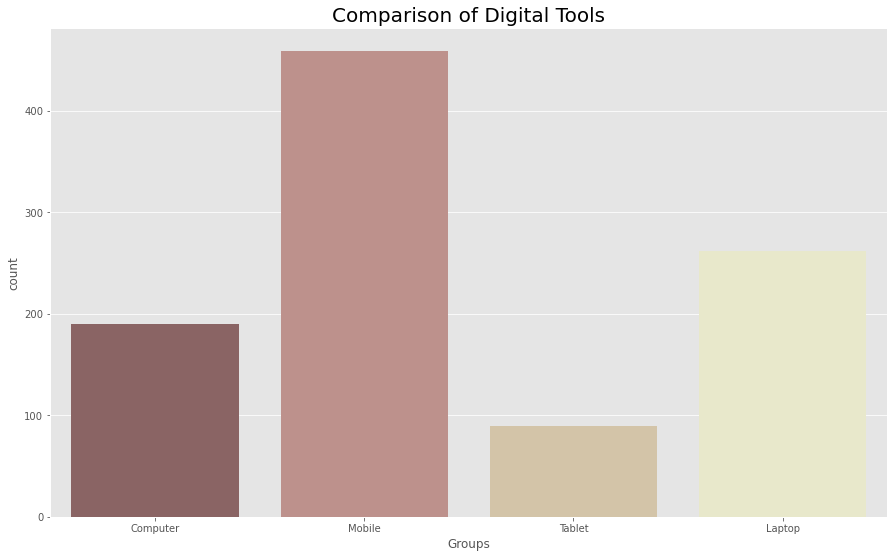

In [17]:
# visualizing the different groups in the dataset

plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('ggplot')

sns.countplot(data['tools'], palette = 'pink')
plt.title('Comparison of Digital Tools', fontweight = 30, fontsize = 20)
plt.xlabel('Groups')
plt.ylabel('count')
plt.show()

D:\Software\Anaconda\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


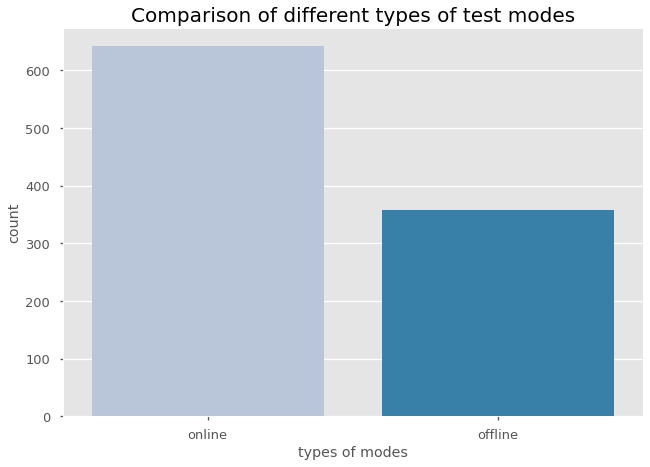

In [18]:
# visualizing different types of test modes

plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('seaborn-talk')

sns.countplot(data['test mode'], palette = 'PuBu')
plt.title('Comparison of different types of test modes', fontweight = 30, fontsize = 20)
plt.xlabel('types of modes')
plt.ylabel('count')
plt.show()

D:\Software\Anaconda\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


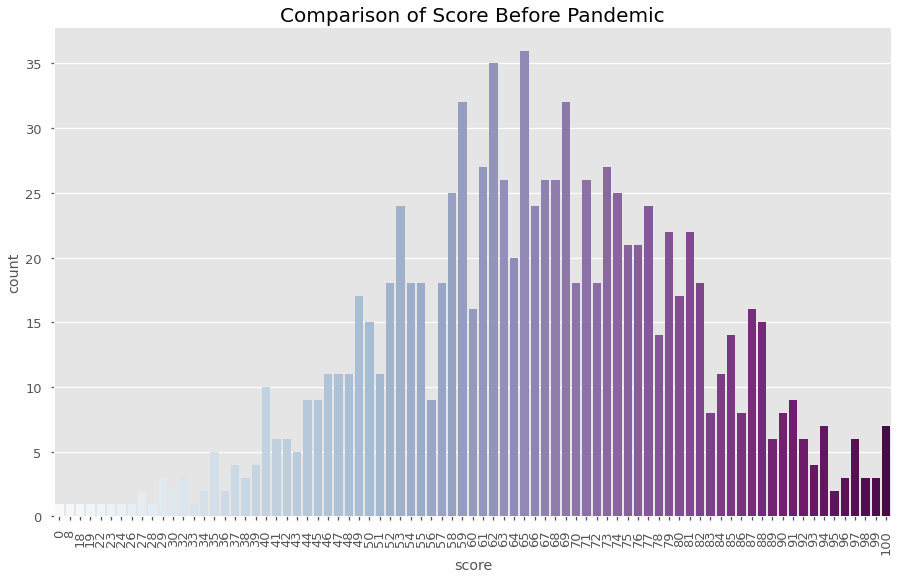

In [19]:
# visualizing score before pandemic

plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('tableau-colorblind10')

sns.countplot(data['score before pandemic'], palette = 'BuPu')
plt.title('Comparison of Score Before Pandemic', fontweight = 30, fontsize = 20)
plt.xlabel('score')
plt.ylabel('count')
plt.xticks(rotation = 90)
plt.show()

D:\Software\Anaconda\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


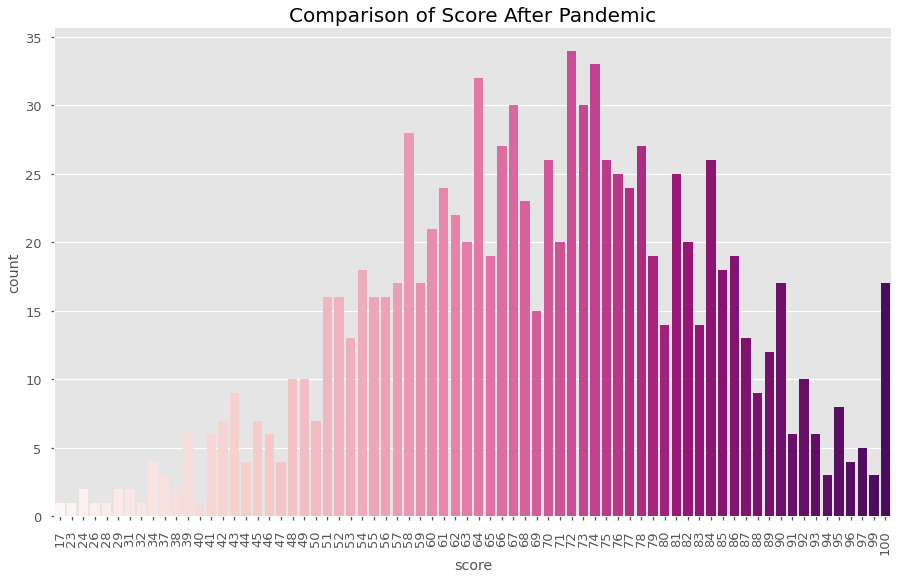

In [20]:
## visualizing score after pandemic

plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('tableau-colorblind10')

sns.countplot(data['score after pandemic'], palette = 'RdPu')
plt.title('Comparison of Score After Pandemic', fontweight = 30, fontsize = 20)
plt.xlabel('score')
plt.ylabel('count')
plt.xticks(rotation = 90)
plt.show()

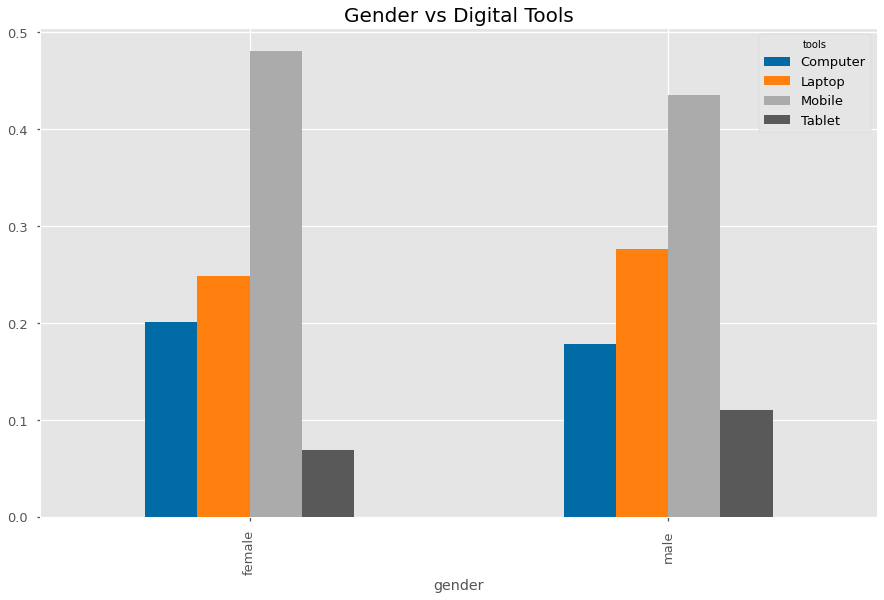

In [21]:
# gender vs digital devices

plt.rcParams['figure.figsize'] = (15, 9)
x = pd.crosstab(data['gender'], data['tools'])
x.div(x.sum(1).astype(float), axis = 0).plot(kind = 'bar', stacked = False)
plt.title('Gender vs Digital Tools', fontweight = 30, fontsize = 20)
plt.show()

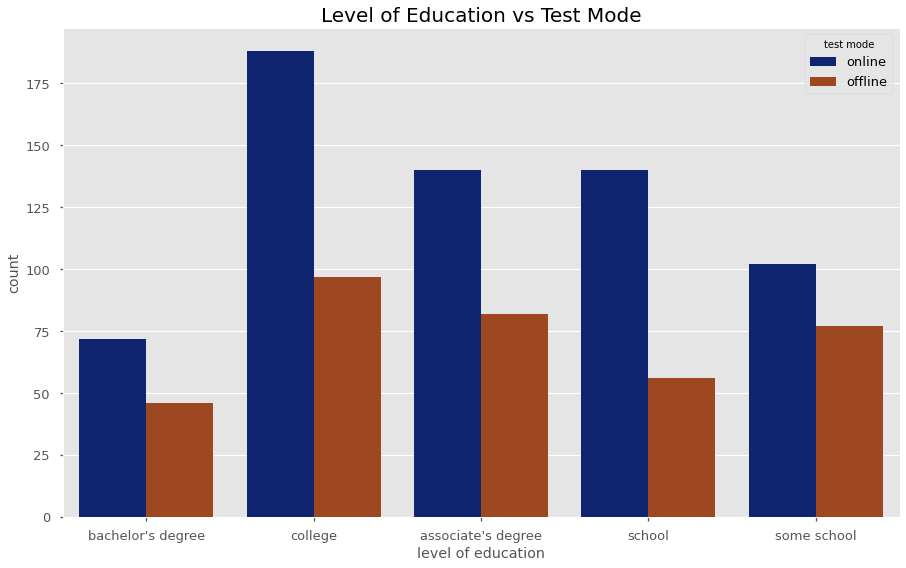

In [22]:
# comparison of level of education degree and test mode

plt.rcParams['figure.figsize'] = (15, 9)
sns.countplot(x = 'level of education', data = data, hue = 'test mode', palette = 'dark')
plt.title('Level of Education vs Test Mode', fontweight = 30, fontsize = 20)
plt.show()

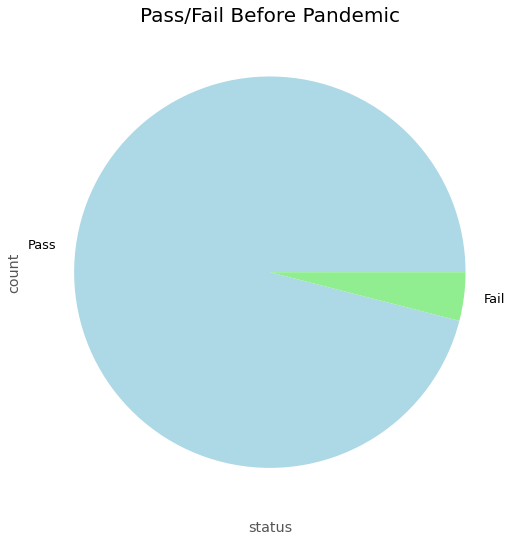

In [23]:
# feature engineering on the data to visualize and solve the dataset more accurately

# setting a passing mark for the students to pass on the two senarios individually
passmarks = 40

# creating a new column pass_before, this column will tell us whether the students are pass or fail
data['pass_before'] = np.where(data['score before pandemic']< passmarks, 'Fail', 'Pass')
data['pass_before'].value_counts().plot.pie(colors = ['lightblue', 'lightgreen'])

plt.title('Pass/Fail Before Pandemic', fontweight = 30, fontsize = 20)
plt.xlabel('status')
plt.ylabel('count')
plt.show()

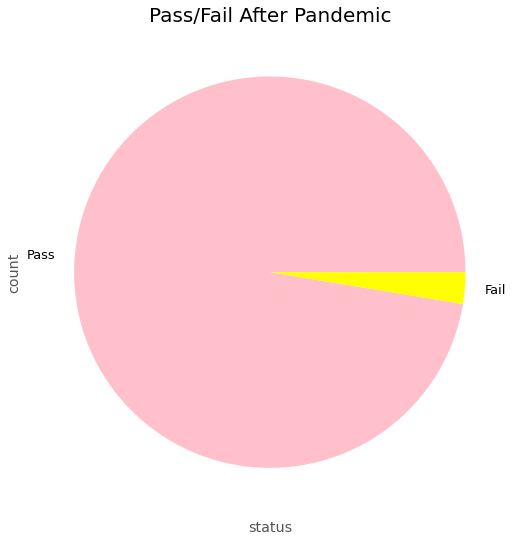

In [24]:
# creating a new column pass_after, this column will tell us whether the students are pass or fail

data['pass_after'] = np.where(data['score after pandemic']< passmarks, 'Fail', 'Pass')
data['pass_after'].value_counts(dropna = False).plot.pie(colors = ['pink', 'yellow'])

plt.title('Pass/Fail After Pandemic', fontweight = 30, fontsize = 20)
plt.xlabel('status')
plt.ylabel('count')
plt.show()

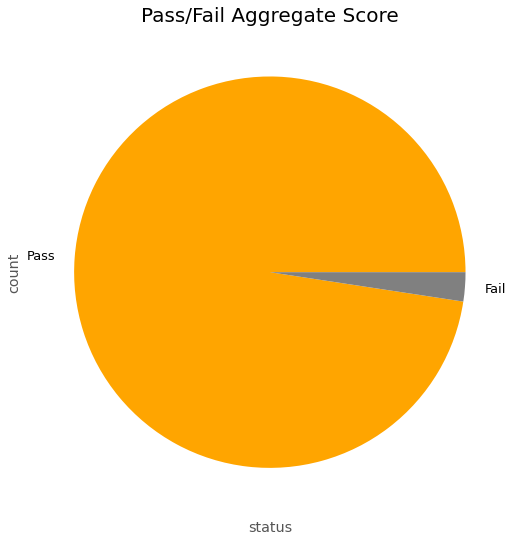

In [25]:
# creating a new column pass_agg, this column will tell us whether the students are pass or fail

data['pass_agg'] = np.where(data['aggregate score']< passmarks, 'Fail', 'Pass')
data['pass_agg'].value_counts(dropna = False).plot.pie(colors = ['orange', 'gray'])

plt.title('Pass/Fail Aggregate Score', fontweight = 30, fontsize = 20)
plt.xlabel('status')
plt.ylabel('count')
plt.show()

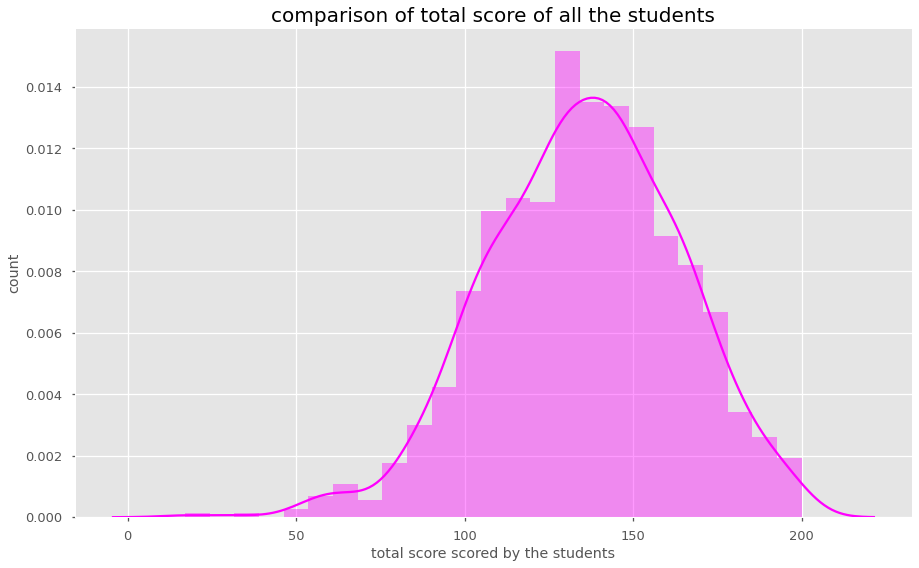

In [26]:
# computing the total score for each student

import warnings
warnings.filterwarnings('ignore')

data['total_score'] = data['score before pandemic'] + data['score after pandemic']

sns.distplot(data['total_score'], color = 'magenta')

plt.title('comparison of total score of all the students', fontweight = 30, fontsize = 20)
plt.xlabel('total score scored by the students')
plt.ylabel('count')
plt.show()

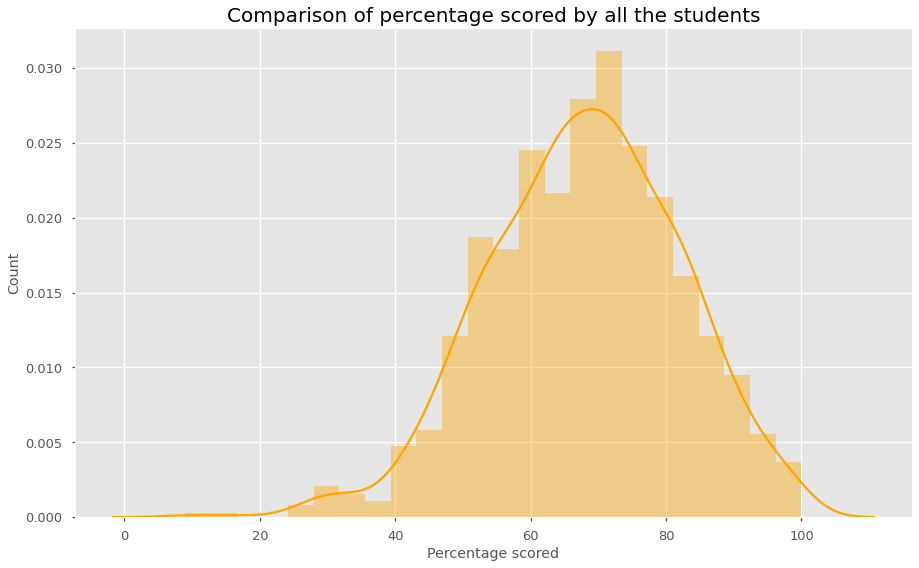

In [27]:
# computing percentage for each of the students
# importing math library to use ceil
from math import * 
import warnings
warnings.filterwarnings('ignore')

data['percentage'] = data['total_score']/2

for i in range(0, 1000):
    data['percentage'][i] = ceil(data['percentage'][i])

plt.rcParams['figure.figsize'] = (15, 9)
sns.distplot(data['percentage'], color = 'orange')

plt.title('Comparison of percentage scored by all the students', fontweight = 30, fontsize = 20)
plt.xlabel('Percentage scored')
plt.ylabel('Count')
plt.show()

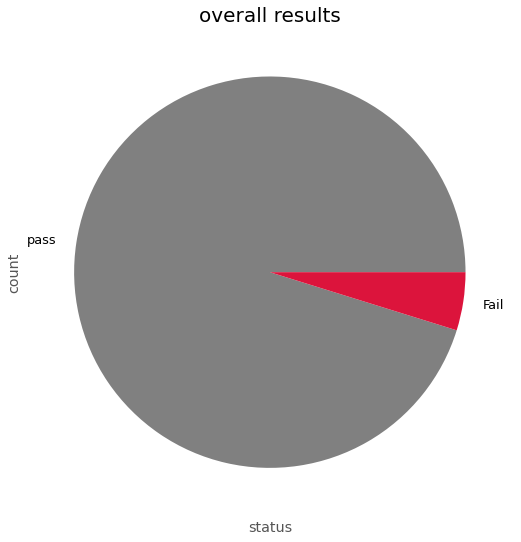

In [28]:
# checking how many students fail overall

data['status'] = data.apply(lambda x : 'Fail' if x['pass_before'] == 'Fail' or 
                           x['pass_after'] == 'Fail' 
                           else 'pass', axis = 1)

data['status'].value_counts(dropna = False).plot.pie(colors = ['grey', 'crimson'])
plt.title('overall results', fontweight = 30, fontsize = 20)
plt.xlabel('status')
plt.ylabel('count')
plt.show()

In [29]:
# Assigning grades to the grades according to the following criteria :
# 0  - 40 marks : grade E
# 41 - 60 marks : grade D
# 60 - 70 marks : grade C
# 70 - 80 marks : grade B
# 80 - 90 marks : grade A
# 90 - 100 marks : grade A+

def getgrade(percentage, status):
  if(percentage >= 90):
    return 'A+'
  if(percentage >= 80):
    return 'A'
  if(percentage >= 70):
    return 'B'
  if(percentage >= 60):
    return 'C'
  if(percentage >= 40):
    return 'D'
  else :
    return 'E'

data['grades'] = data.apply(lambda x: getgrade(x['percentage'], x['status']), axis = 1 )

data['grades'].value_counts()

D     254
C     252
B     248
A     165
A+     58
E      23
Name: grades, dtype: int64

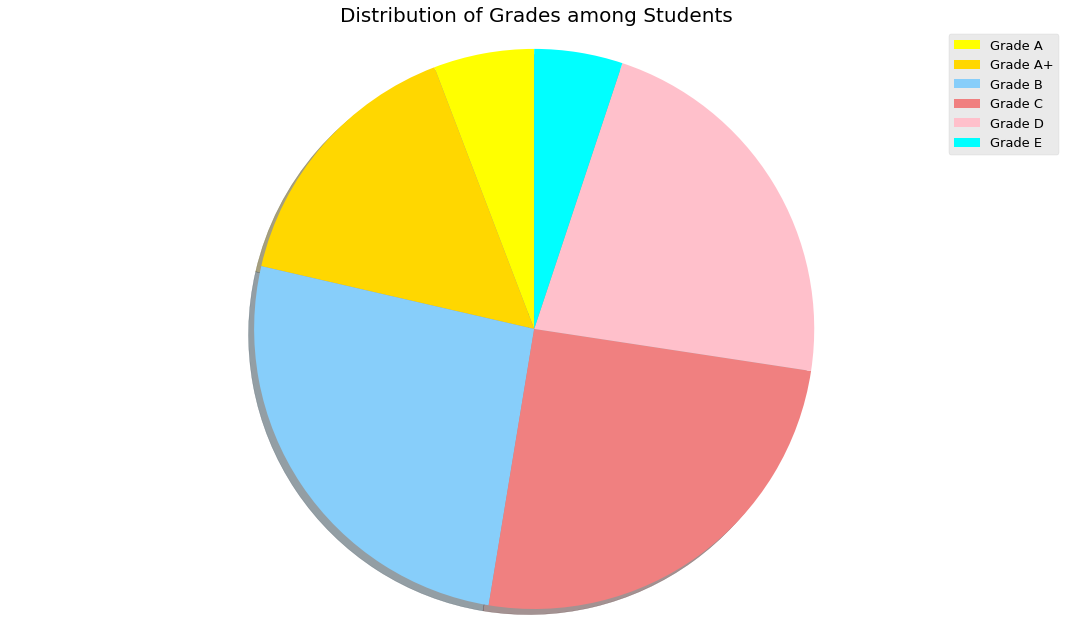

In [30]:
# plotting a pie chart for the distribution of various grades amongst the students

labels = ['Grade A', 'Grade A+', 'Grade B', 'Grade C', 'Grade D', 'Grade E']
sizes = [58, 156, 260, 252, 223, 51]
colors = ['yellow', 'gold', 'lightskyblue', 'lightcoral', 'pink', 'cyan']
explode = (0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001)

patches, texts = plt.pie(sizes, colors=colors, shadow=True, startangle=90)
plt.legend(patches, labels)
plt.title('Distribution of Grades among Students', fontweight = 30, fontsize = 20)
plt.axis('equal')
plt.tight_layout()
plt.show()

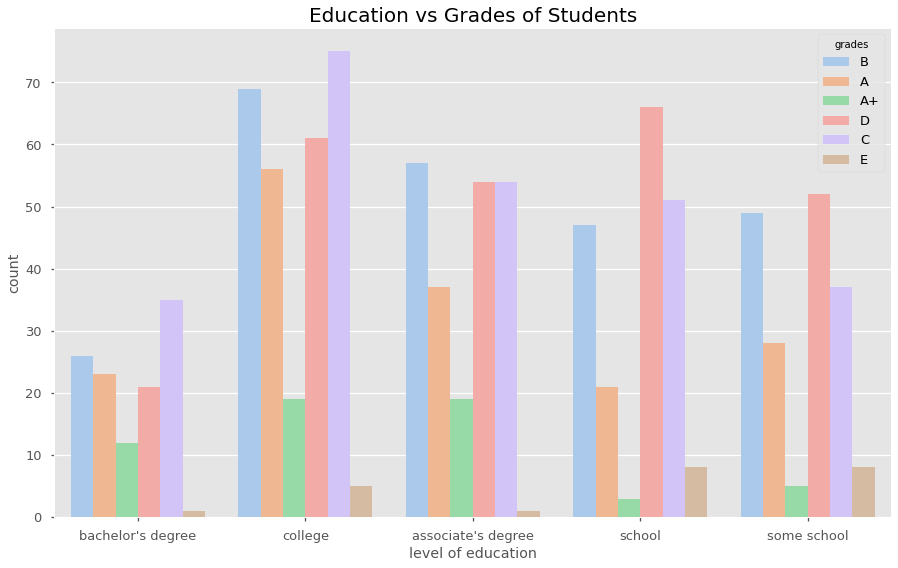

In [31]:
# for better visualization we will plot it again using seaborn

sns.countplot(x = data['level of education'], data = data, hue = data['grades'], palette = 'pastel')
plt.title('Education vs Grades of Students', fontsize = 20, fontweight = 30)
plt.show()

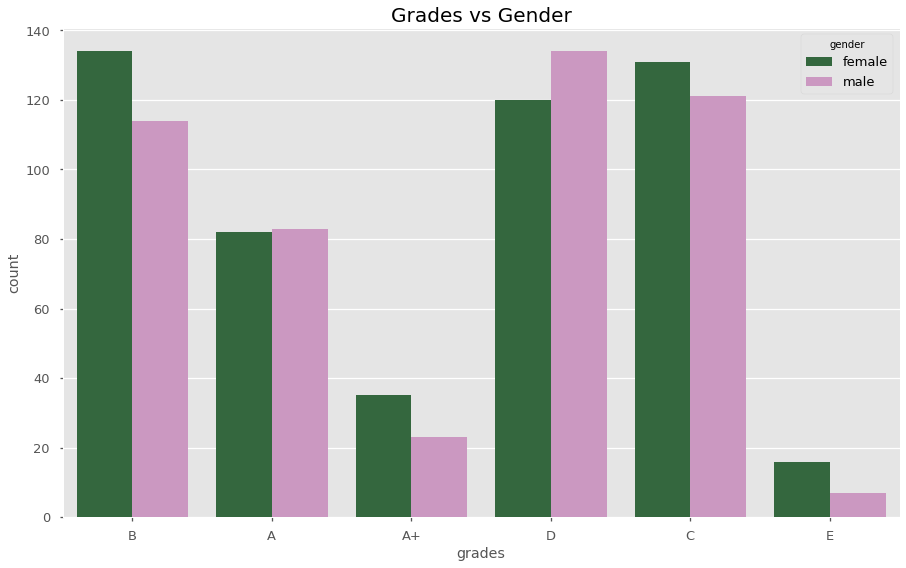

In [32]:
# comparing the distribution of grades among males and females

sns.countplot(x = data['grades'], data = data, hue = data['gender'], palette = 'cubehelix')
#sns.palplot(sns.dark_palette('purple'))
plt.title('Grades vs Gender', fontweight = 30, fontsize = 20)
plt.show()

## Label Encoding

In [33]:
from sklearn.preprocessing import LabelEncoder

# creating an encoder
le = LabelEncoder()

# label encoding for test preparation course
data['test mode'] = le.fit_transform(data['test mode'])

# label encoding for mental health
data['mental health'] = le.fit_transform(data['mental health'])

# label encoding for digital tools
# we have to map values to each of the categories
data['tools'] = data['tools'].replace('Mobile', 1)
data['tools'] = data['tools'].replace('Computer', 2)
data['tools'] = data['tools'].replace('Laptop', 3)
data['tools'] = data['tools'].replace('Tablet', 4)

# label encoding for level of education
data['level of education'] = le.fit_transform(data['level of education'])

#label encoding for gender
data['gender'] = le.fit_transform(data['gender'])

# label encoding for pass_before
data['pass_before'] = le.fit_transform(data['pass_before'])

# label encoding for pass_after
data['pass_after'] = le.fit_transform(data['pass_after'])

# label encoding for pass_aggregate
data['pass_agg'] = le.fit_transform(data['pass_agg'])

# label encoding for status
data['status'] = le.fit_transform(data['status'])

### Data Preparation

In [34]:
# splitting the dependent and independent variables

x = data.iloc[:,:14]
y = data.iloc[:,14]

print(x.shape)
print(y.shape)

(1000, 14)
(1000,)


In [35]:
# splitting the dataset into training and test sets

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state = 45)

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(750, 14)
(750,)
(250, 14)
(250,)


In [36]:
# importing the MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

# creating a scaler
mm = MinMaxScaler()

# feeding the independent variable into the scaler
x_train = mm.fit_transform(x_train)
x_test = mm.transform(x_test)

## Modelling

## Logistic Regression

In [37]:
from sklearn.linear_model import  LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

# creating a model
model = LogisticRegression()

# feeding the training data to the model
model.fit(x_train, y_train)

# predicting the test set results
y_pred = model.predict(x_test)

# calculating the classification accuracies
print("Training Accuracy :", model.score(x_train, y_train))
print("Testing Accuracy :", model.score(x_test, y_test))


Training Accuracy : 0.8546666666666667
Testing Accuracy : 0.848


## Hyperparameter tuning

In [38]:
from sklearn.model_selection import GridSearchCV,RepeatedStratifiedKFold

cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
# defining parameter range
param_grid = {'solver': ['lbfgs'],
			'penalty': ['l2'],
			'C': [0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(model, param_grid, scoring='accuracy', refit = True, verbose = 3, cv=cv)

# fitting the model for grid search
grid.fit(x_train, y_train)

Fitting 30 folds for each of 5 candidates, totalling 150 fits
[CV 1/30] END ..............C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV 2/30] END ..............C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV 3/30] END ..............C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV 4/30] END ..............C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV 5/30] END ..............C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV 6/30] END ..............C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV 7/30] END ..............C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV 8/30] END ..............C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV 9/30] END ..............C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV 10/30] END .............C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV 11/30] END .............C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV 12/30] END .............C=0.01, penalty=l2,

[CV 12/30] END ...............C=10, penalty=l2, solver=lbfgs; total time=   0.0s
[CV 13/30] END ...............C=10, penalty=l2, solver=lbfgs; total time=   0.0s
[CV 14/30] END ...............C=10, penalty=l2, solver=lbfgs; total time=   0.0s
[CV 15/30] END ...............C=10, penalty=l2, solver=lbfgs; total time=   0.0s
[CV 16/30] END ...............C=10, penalty=l2, solver=lbfgs; total time=   0.0s
[CV 17/30] END ...............C=10, penalty=l2, solver=lbfgs; total time=   0.0s
[CV 18/30] END ...............C=10, penalty=l2, solver=lbfgs; total time=   0.0s
[CV 19/30] END ...............C=10, penalty=l2, solver=lbfgs; total time=   0.0s
[CV 20/30] END ...............C=10, penalty=l2, solver=lbfgs; total time=   0.0s
[CV 21/30] END ...............C=10, penalty=l2, solver=lbfgs; total time=   0.0s
[CV 22/30] END ...............C=10, penalty=l2, solver=lbfgs; total time=   0.0s
[CV 23/30] END ...............C=10, penalty=l2, solver=lbfgs; total time=   0.0s
[CV 24/30] END .............

GridSearchCV(cv=RepeatedStratifiedKFold(n_repeats=3, n_splits=10, random_state=1),
             estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l2'],
                         'solver': ['lbfgs']},
             scoring='accuracy', verbose=3)

In [39]:
grid_predictions_rf = grid.predict(x_test)
# print classification report
print(classification_report(y_test, grid_predictions_rf))

              precision    recall  f1-score   support

           A       0.97      0.97      0.97        36
          A+       0.92      0.92      0.92        12
           B       0.97      1.00      0.98        62
           C       0.97      0.95      0.96        60
           D       0.99      0.96      0.97        75
           E       0.83      1.00      0.91         5

    accuracy                           0.97       250
   macro avg       0.94      0.97      0.95       250
weighted avg       0.97      0.97      0.97       250



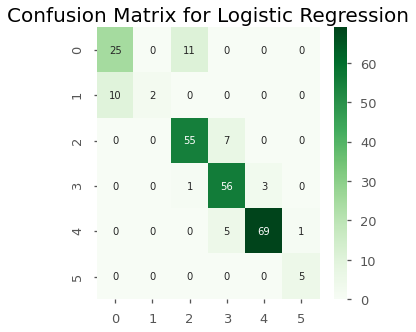

In [40]:
# printing the confusion matrix
# creating a confusion matrix
cm = confusion_matrix(y_test, y_pred)

# printing the confusion matrix
plt.rcParams['figure.figsize'] = (5, 5)
sns.heatmap(cm, annot = True, cmap = 'Greens')
plt.title('Confusion Matrix for Logistic Regression', fontweight = 30, fontsize = 20)
plt.show()

In [41]:
# print best parameter after tuning
print(grid.best_params_)
 
# print how our model looks after hyper-parameter tuning
print(grid.best_estimator_)

{'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
LogisticRegression(C=100)


In [42]:
# Creating a model with best parameters
model = LogisticRegression(C=100)

# feeding the training data to the model
model.fit(x_train, y_train)

# predicting the test set results
y_pred = model.predict(x_test)
score1 = accuracy_score(y_test,y_pred)
print("---- Scores ----")
print("Accuracy score is: {}%".format(round(score1*100,2)))

---- Scores ----
Accuracy score is: 96.8%


- After Hyperparameter Tuning we got from 84% to 96.8% accuracy with,LogisticRegression(C=100).

# Random Forest

In [43]:
from sklearn.ensemble import RandomForestClassifier

# creating a model
model = RandomForestClassifier()

# feeding the training data to the model
model.fit(x_train, y_train)

# predicting the x-test results
y_pred = model.predict(x_test)

# calculating the accuracies
print("Training Accuracy :", model.score(x_train, y_train))
print("Testing Accuracy :", model.score(x_test, y_test))

Training Accuracy : 1.0
Testing Accuracy : 0.996


## Hyperparameter tuning

In [44]:
# defining parameter range
param_grid = {'n_estimators': [10, 100, 1000],
			'max_features': ['sqrt', 'log2']}

grid = GridSearchCV(RandomForestClassifier(), param_grid, refit = True, verbose = 3)

# fitting the model for grid search
grid.fit(x_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV 1/5] END .............max_features=sqrt, n_estimators=10; total time=   0.0s
[CV 2/5] END .............max_features=sqrt, n_estimators=10; total time=   0.0s
[CV 3/5] END .............max_features=sqrt, n_estimators=10; total time=   0.0s
[CV 4/5] END .............max_features=sqrt, n_estimators=10; total time=   0.0s
[CV 5/5] END .............max_features=sqrt, n_estimators=10; total time=   0.0s
[CV 1/5] END ............max_features=sqrt, n_estimators=100; total time=   0.2s
[CV 2/5] END ............max_features=sqrt, n_estimators=100; total time=   0.2s
[CV 3/5] END ............max_features=sqrt, n_estimators=100; total time=   0.2s
[CV 4/5] END ............max_features=sqrt, n_estimators=100; total time=   0.2s
[CV 5/5] END ............max_features=sqrt, n_estimators=100; total time=   0.2s
[CV 1/5] END ...........max_features=sqrt, n_estimators=1000; total time=   2.3s
[CV 2/5] END ...........max_features=sqrt, n_esti

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'max_features': ['sqrt', 'log2'],
                         'n_estimators': [10, 100, 1000]},
             verbose=3)

In [45]:
grid_predictions_rf = grid.predict(x_test)
# print classification report
print(classification_report(y_test, grid_predictions_rf))

              precision    recall  f1-score   support

           A       1.00      1.00      1.00        36
          A+       1.00      1.00      1.00        12
           B       1.00      1.00      1.00        62
           C       1.00      1.00      1.00        60
           D       1.00      0.99      0.99        75
           E       0.83      1.00      0.91         5

    accuracy                           1.00       250
   macro avg       0.97      1.00      0.98       250
weighted avg       1.00      1.00      1.00       250



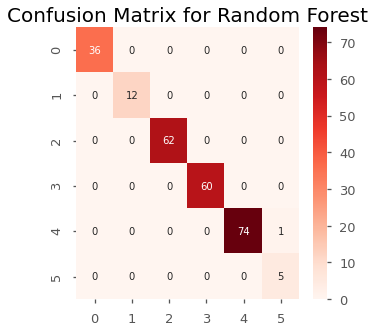

In [46]:
# printing the confusion matrix
from sklearn.metrics import classification_report,confusion_matrix

# creating a confusion matrix
cm = confusion_matrix(y_test, y_pred)

# printing the confusion matrix
plt.rcParams['figure.figsize'] = (5, 5)
sns.heatmap(cm, annot = True, cmap = 'Reds')
plt.title('Confusion Matrix for Random Forest', fontweight = 30, fontsize = 20)
plt.show()

In [47]:
# print best parameter after tuning
print(grid.best_params_)
 
# print how our model looks after hyper-parameter tuning
print(grid.best_estimator_)

{'max_features': 'sqrt', 'n_estimators': 100}
RandomForestClassifier(max_features='sqrt')


In [48]:
# Creating a model with best parameters
model = RandomForestClassifier(max_features='sqrt')

# feeding the training data to the model
model.fit(x_train, y_train)

# predicting the x-test results
y_pred = model.predict(x_test)
# Accuracy
score1 = accuracy_score(y_test,y_pred)
print("---- Scores ----")
print("Accuracy score is: {}%".format(round(score1*100,2)))

---- Scores ----
Accuracy score is: 99.6%
